# R&D notebook

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import filters, morphology, measure, color, util
from skimage import io
from skimage.transform import AffineTransform, warp
from skimage.filters import gaussian
from skimage.draw import line

from scipy import ndimage as ndi
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import label
from scipy.optimize import minimize

# Data input and preprocessing

### Beads demo data

(2000, 1500)


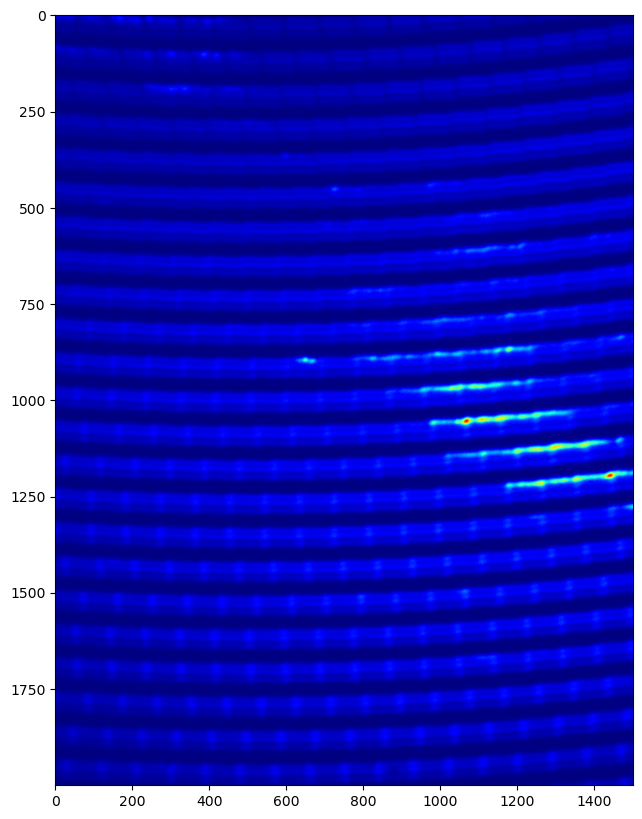

In [5]:
ph_img_raw = io.imread('data/QD_mix_40_phase/Basler_boA4096-180cm__40460831__20260320_123758244_0000.tiff')[500:2500, 1000:2500]
print(ph_img_raw.shape)

plt.figure(figsize=(10, 10))
plt.imshow(ph_img_raw, cmap='jet')

### Real experimental demo data

(2000, 1500)


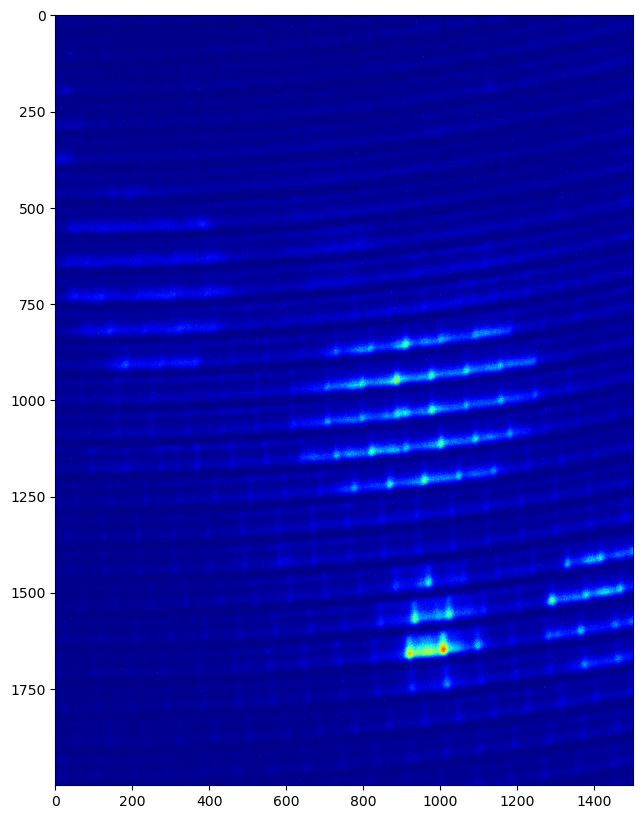

In [6]:
ph_img_exp = io.imread('data/CS1_4/Basler_boA4096-180cm__40460831__20260520_145009511_0000.tiff')[500:2500, 1000:2500]
print(ph_img_exp.shape)

plt.figure(figsize=(10, 10))
plt.imshow(ph_img_exp, cmap='jet')

# Disk simulation based spectral bands detection

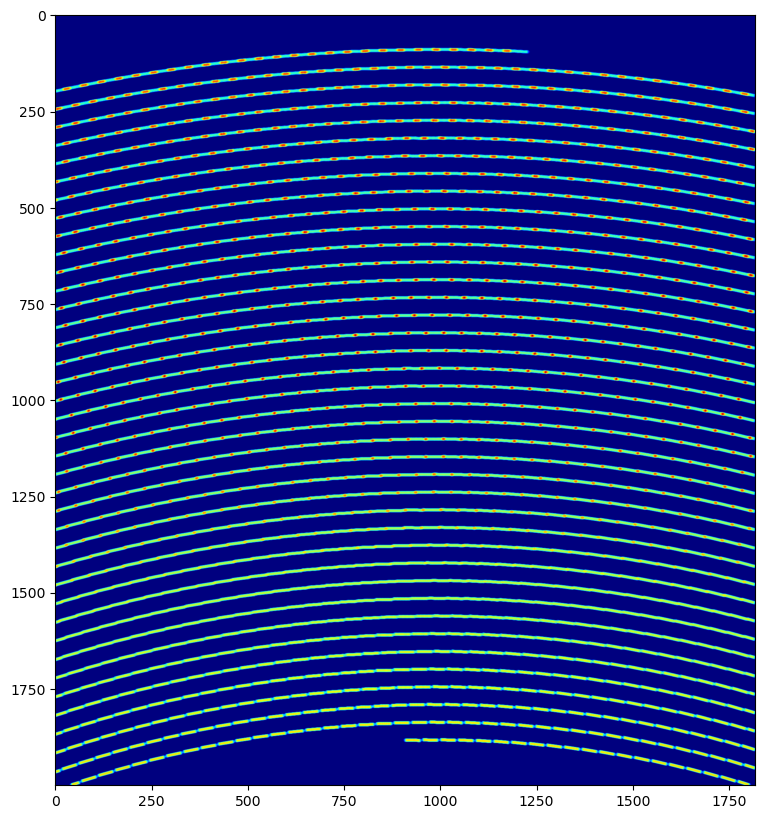

In [8]:
disk_simulated = io.imread('disk_sim/simulated_img.tiff')

plt.figure(figsize=(10, 10))
plt.imshow(disk_simulated, cmap='jet')

In [17]:
def generate_spline_raster(sim_image: np.ndarray)-> tuple[np.ndarray, np.ndarray]:
    """ Fitting of the simulated image with a spline and rasterization of the spline to create a binary image.

    """
    binary = sim_image > 0.1 * np.max(sim_image)
    labeled, num_features = label(binary)

    h, w = sim_image.shape
    raster_splines = np.zeros_like(sim_image, dtype=float)
    raster_1px = np.zeros((h, w), dtype=np.uint8)
    
    for i in range(1, num_features + 1):
        y_idx, x_idx = np.where(labeled == i)
        if len(x_idx) < 10:
            continue
            
        sort_idx = np.argsort(x_idx)
        x_sorted = x_idx[sort_idx]
        y_sorted = y_idx[sort_idx]
        
        x_unique, unique_indices = np.unique(x_sorted, return_index=True)
        if len(x_unique) < 5:
            continue
        y_unique = y_sorted[unique_indices]
        
        spline = UnivariateSpline(x_unique, y_unique, k=3, s=1)
        
        x_dense = np.linspace(x_unique[0], x_unique[-1], int(2 * (x_unique[-1] - x_unique[0])))
        y_dense = spline(x_dense)
        
        x_pixels = np.round(x_dense).astype(int)
        y_pixels = np.round(y_dense).astype(int)
        
        valid = (x_pixels >= 0) & (x_pixels < w) & (y_pixels >= 0) & (y_pixels < h)
        raster_splines[y_pixels[valid], x_pixels[valid]] = 1.0

        x_nodes = np.arange(int(x_unique[0]), int(x_unique[-1]) + 1)
        y_nodes = np.round(spline(x_nodes)).astype(int)
        
        for j in range(len(x_nodes) - 1):
            r0, c0 = y_nodes[j], x_nodes[j]
            r1, c1 = y_nodes[j+1], x_nodes[j+1]
            
            if 0 <= r0 < h and 0 <= c0 < w and 0 <= r1 < h and 0 <= c1 < w:
                rr, cc = line(r0, c0, r1, c1)
                raster_1px[rr, cc] = 1
        
    return raster_splines, raster_1px

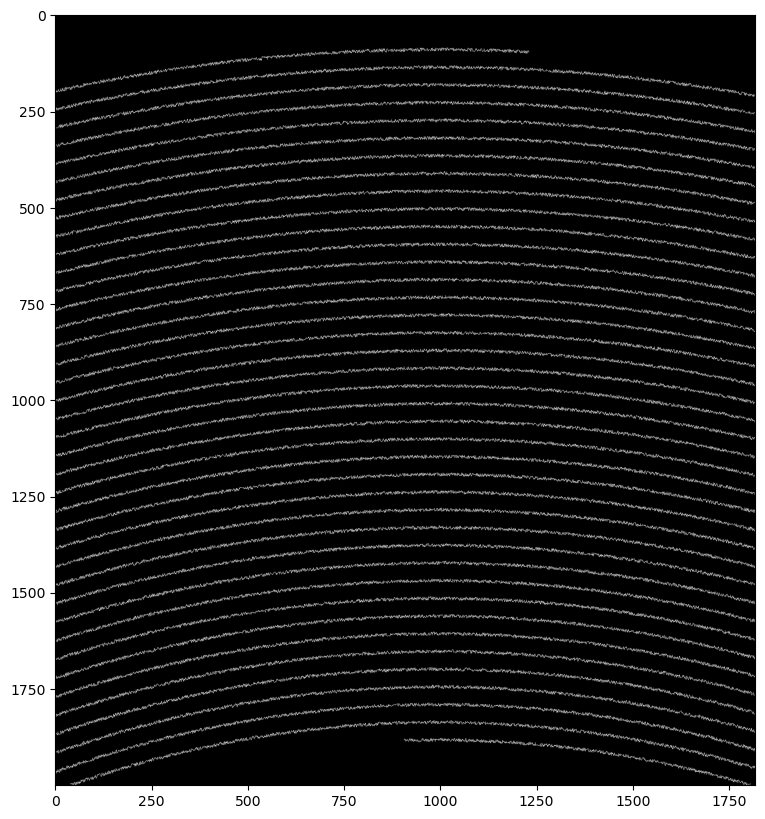

In [18]:
disk_spline, disk_1px = generate_spline_raster(disk_simulated)

plt.figure(figsize=(10, 10))
plt.imshow(disk_1px, cmap='gray')

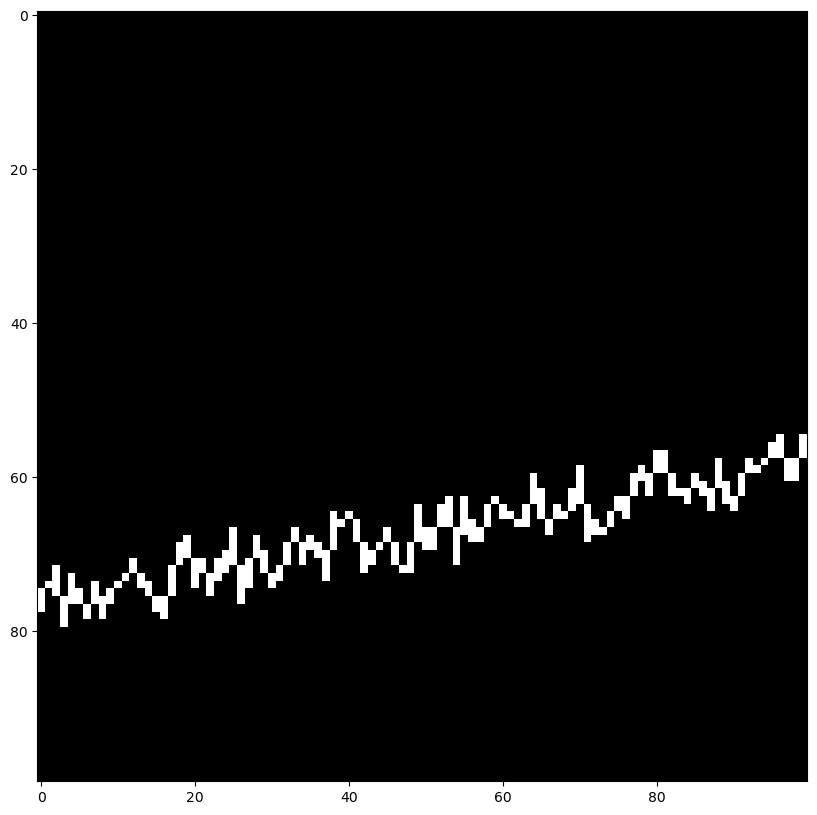

In [21]:
plt.figure(figsize=(10, 10))
plt.imshow(disk_1px[100:200, 100:200], cmap='gray')

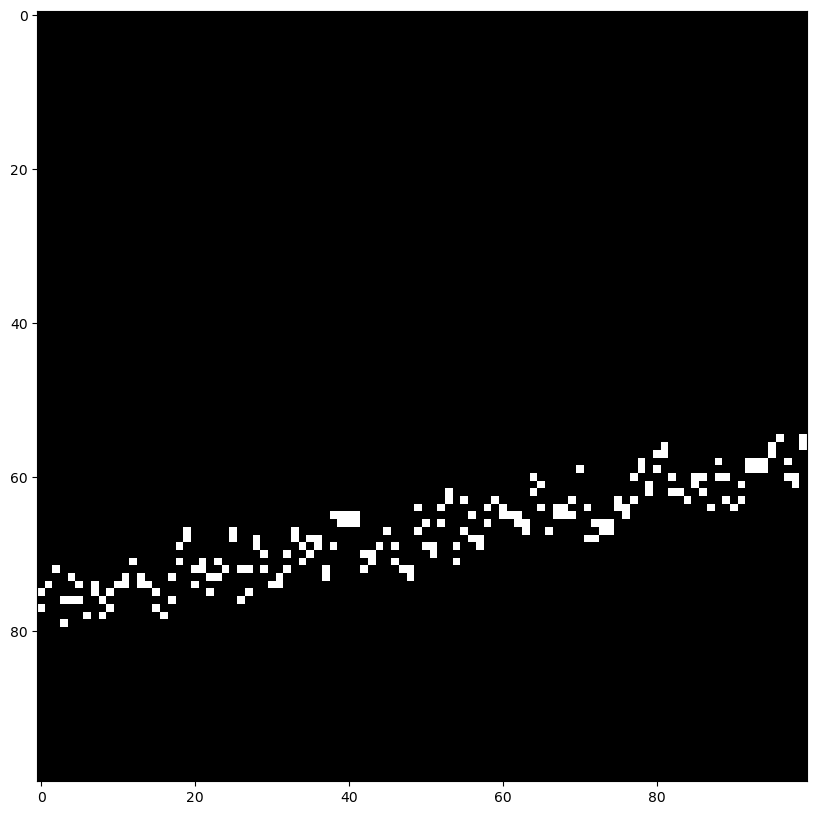

In [22]:
plt.figure(figsize=(10, 10))
plt.imshow(disk_spline[100:200, 100:200], cmap='gray')

# Blind spectral bands detection

In [ ]:
prewitt_img = ndi.prewitt(ph_img_raw, axis=0)
# prewitt_fil_img = ndi.prewitt(ndi.median_filter(ph_img_raw, size=5), axis=0)
sobel_img = ndi.sobel(ph_img_raw, axis=0)

plt.figure(figsize=(15, 15))
plt.subplot(1, 2, 1), plt.imshow(prewitt_img, cmap='gray'), plt.title('Prewitt Filtered Image')
plt.subplot(1, 2, 2), plt.imshow(sobel_img, cmap='gray'), plt.title('Sobel Filtered Image')
# plt.subplot(1, 3, 3), plt.imshow(prewitt_fil_img, cmap='gray'), plt.title('Prewitt Filtered Image (Median Filtered)')

### Bright lines detection

In [ ]:
import numpy as np
from scipy import ndimage

def extract_lines_dp(image: np.ndarray, num_lines: int, mask_width: int = 3) -> np.ndarray:
    """
    Iteratively extracts lines from a Prewitt-filtered image using dynamic programming to find the optimal path of maximum gradient response.
    
    Parameters
    ----------
    image : np.ndarray
        input Prewitt-filtered image (2D array)
    num_lines : int
        number of lines to detect
    mask_width : int
        depletion mask width (in pixels) around the detected line to prevent finding the same line again
        
    Returns
    -------
    np.ndarray
        Array (num_lines, cols), with line coordinates in each line
    """
    img_work = ndimage.gaussian_filter(image.astype(np.float64), sigma=(1.0, 2.0))
    rows, cols = img_work.shape
    lines = np.zeros((num_lines, cols), dtype=np.int32)

    mask_value = np.max(img_work) + 1000.0
    
    for line_idx in range(num_lines):
        acc = np.zeros_like(img_work)
        acc[:, 0] = img_work[:, 0]
        ptr = np.zeros_like(img_work, dtype=np.int32)
        
        for j in range(1, cols):
            v_up = np.pad(acc[:-1, j-1], (1, 0), constant_values=-np.inf)
            v_st = acc[:, j-1]
            v_dn = np.pad(acc[1:, j-1], (0, 1), constant_values=-np.inf)
            
            stacked = np.stack([v_up, v_st, v_dn])
            
            acc[:, j] = img_work[:, j] + np.max(stacked, axis=0)
            ptr[:, j] = np.argmax(stacked, axis=0) - 1 

        path = np.zeros(cols, dtype=np.int32)
        path[-1] = np.argmax(acc[:, -1])
        
        for j in range(cols - 1, 0, -1):
            curr_row = path[j]
            path[j-1] = np.clip(curr_row + ptr[curr_row, j], 0, rows - 1)
            
        lines[line_idx] = path
        
        for j in range(cols):
            r = path[j]
            r_min = max(0, r - mask_width)
            r_max = min(rows, r + mask_width + 1)
            img_work[r_min:r_max, j] = 0.0
            
    return lines

In [ ]:
lines_img = extract_lines_dp(prewitt_img, num_lines=20, mask_width=20)

plt.figure(figsize=(10, 10))
plt.imshow(prewitt_img, cmap='gray')
for line in lines_img:
    plt.plot(np.arange(prewitt_img.shape[1]), line, color='red', linewidth=3)
plt.title('Detected Lines on Prewitt Filtered Image')
plt.show()

### Bands detection

__Light Line Detection__

$$S_{max}(i, j) = I(i, j) + \max_{k \in \{-1, 0, 1\}} S_{max}(i+k, j-1)$$

Objective function for the extraction of continuous light structures. The algorithm iteratively computes the maximum cumulative intensity matrix, Smax​. The value of each node (i,j) is defined as the sum of the local pixel intensity I(i,j) and the maximum accumulated value from three adjacent nodes in the preceding column j−1. This formulation guarantees the identification of the globally optimal path with the highest overall brightness.

__Dark Line Detection__

$$S_{min}(i, j) = I(i, j) + \min_{k \in \{-1, 0, 1\}} S_{min}(i+k, j-1)$$

Objective function for the extraction of continuous dark structures. The algorithm constructs the minimum cumulative cost matrix, Smin​. The value at point (i,j) is calculated by adding the local intensity I(i,j) to the minimum accumulated value from the local neighborhood in the preceding column j−1. This minimizes the total intensity along the graph, ensuring the localization of the darkest optimal path.

In both equations, i∈[0,M−1] represents the spatial row coordinate, j∈[1,N−1] denotes the column coordinate, and k constrains the spatial derivative of the path, restricting transitions exclusively to adjacent pixels.

__Backtracking__

$$P(i, j) = \text{arg}\max_{k \in \{-1, 0, 1\}} S(i+k, j-1)$$
$$y(N-1) = \text{arg}\max_{i \in [0, M-1]} S(i, N-1)$$
$$y(j-1) = y(j) + P(y(j), j), \quad \forall j \in \{N-1, \dots, 1\}$$

The backtracking phase reconstructs the spatial coordinates of the optimal continuous structure, denoted as y(j), iterating from the last column N−1 back to the first. During the forward pass, a pointer matrix P(i,j) is constructed to record the optimal spatial transition k∈{−1,0,1} chosen to reach each node (i,j). The sequence is initialized by finding the global extremum (maximum for light structures, minimum for dark structures) in the final column of the cumulative cost matrix S. The optimal path is then iteratively traced backward using the stored spatial offsets.

__Spatial Period Estimation__

$$P(y) = \text{median}_{x \in [0, N-1]} I(y, x)$$
$$\bar{P}(y) = P(y) - \frac{1}{M}\sum_{k=0}^{M-1} P(k)$$
$$R(\tau) = \sum_{y=0}^{M-\tau-1} \bar{P}(y) \bar{P}(y+\tau)$$
$$T = \text{arg}\max_{\tau > 0} R(\tau)$$
$$N \approx \lfloor M / T \rfloor$$

The automatic estimation of the spatial period is based on the 1D autocorrelation of the image's vertical intensity profile. First, a robust spatial profile P(y) is extracted by calculating the median intensity along the horizontal axis x to suppress localized noise. The DC component is subsequently removed to produce a zero-mean signal Pˉ(y). The discrete autocorrelation function R(τ) is then computed for spatial lags τ. The spatial period T (the distance between adjacent ridges or valleys) is identified by locating the first prominent global maximum of R(τ) at τ>0. The expected number of continuous structures N is approximated by dividing the total image height M by the estimated period T.

In [ ]:
import numpy as np
from scipy import ndimage, signal

def extract_periodic_structures_dp(image: np.ndarray, mask_width: int = 3) -> dict:
    """
    Automatic detection of periodic structures (both light and dark lines) using dynamic programming.
    
    Parameters
    ----------
    image : np.ndarray
        Input 2D image.
    mask_width : int
        Half-width of the window for suppression after finding a line.
        
    Повертає:
    -------
    dict
        Dictionary with keys 'light' and 'dark', containing arrays of row coordinates.
    """
    img_work = ndimage.gaussian_filter(image.astype(np.float64), sigma=(1.0, 2.0))
    rows, cols = img_work.shape

    # Automatic determination of the number of lines through autocorrelation
    profile = np.median(img_work, axis=1)
    profile -= np.mean(profile)
    
    autocorr = signal.correlate(profile, profile, mode='full')
    autocorr = autocorr[autocorr.size // 2:]
    
    # Peaks in autocorrelation correspond to the period of the structure
    peaks, _ = signal.find_peaks(autocorr, distance=10)
    period = peaks[0] if len(peaks) > 0 else rows
    num_lines = max(1, rows // period)

    # Path extraction function for both light and dark lines
    def _extract_paths(is_dark: bool) -> np.ndarray:
        img_copy = img_work.copy()
        lines = np.zeros((num_lines, cols), dtype=np.int32)
        
        mask_val = np.max(img_copy) + 1000.0 if is_dark else np.min(img_copy) - 1000.0
        pad_val = np.inf if is_dark else -np.inf
        
        for line_idx in range(num_lines):
            acc = np.zeros_like(img_copy)
            acc[:, 0] = img_copy[:, 0]
            ptr = np.zeros_like(img_copy, dtype=np.int32)
            
            for j in range(1, cols):
                v_up = np.pad(acc[:-1, j-1], (1, 0), constant_values=pad_val)
                v_st = acc[:, j-1]
                v_dn = np.pad(acc[1:, j-1], (0, 1), constant_values=pad_val)
                
                stacked = np.stack([v_up, v_st, v_dn])
                
                if is_dark:
                    acc[:, j] = img_copy[:, j] + np.min(stacked, axis=0)
                    ptr[:, j] = np.argmin(stacked, axis=0) - 1
                else:
                    acc[:, j] = img_copy[:, j] + np.max(stacked, axis=0)
                    ptr[:, j] = np.argmax(stacked, axis=0) - 1

            path = np.zeros(cols, dtype=np.int32)
            path[-1] = np.argmin(acc[:, -1]) if is_dark else np.argmax(acc[:, -1])
            
            for j in range(cols - 1, 0, -1):
                curr_row = path[j]
                path[j-1] = np.clip(curr_row + ptr[curr_row, j], 0, rows - 1)
                
            lines[line_idx] = path
            
            for j in range(cols):
                r = path[j]
                r_min = max(0, r - mask_width)
                r_max = min(rows, r + mask_width + 1)
                img_copy[r_min:r_max, j] = mask_val
                
        return np.sort(lines, axis=0)

    return {
        'light': _extract_paths(is_dark=False),
        'dark': _extract_paths(is_dark=True)
    }

In [ ]:
lines_dict = extract_periodic_structures_dp(prewitt_img, mask_width=20)

plt.figure(figsize=(10, 10))
plt.imshow(prewitt_img, cmap='gray')
for line in lines_dict['light']:
    plt.plot(np.arange(prewitt_img.shape[1]), line, color='red', linewidth=3)
for line in lines_dict['dark']:
    plt.plot(np.arange(prewitt_img.shape[1]), line, color='blue', linewidth=3)
plt.title('Detected Lines on Prewitt Filtered Image')
plt.show()

### Smoothing and interpolation

In [ ]:
def regularize_periodic_structures(detected_lines: dict, 
                                   smooth_factor: float = 1e5, 
                                   dist_up: float = None, 
                                   dist_down: float = None) -> dict:
    """
    Light lines are approximated with B-splines, and dark lines are generated at regular distances from them.
    """
    light_lines = detected_lines.get('light', [])
    dark_lines = detected_lines.get('dark', [])
    cols = detected_lines['light'].shape[1]
    
    if len(light_lines) == 0:
        return {} 

    x_vals = np.arange(cols)
    splined_light = np.zeros_like(light_lines, dtype=np.float64)
    
    # Light lines approximation with B-splines
    for i, line in enumerate(light_lines):
        spline = UnivariateSpline(x_vals, line, s=smooth_factor)
        splined_light[i] = spline(x_vals)

    # Automatic estimation of offsets (if not specified explicitly)
    if dist_up is None or dist_down is None:
        estimated_up, estimated_down = [], []
        for i, l_line in enumerate(splined_light):
            # Search for the nearest dark line above (smaller indices) and below (larger indices)
            dists = [d_line - l_line for d_line in dark_lines]
            dists_mean = np.mean(dists, axis=1)
            
            above = dists_mean[dists_mean < -5] # Threshold for excluding overlaps
            below = dists_mean[dists_mean > 5]
            
            if len(above) > 0:
                estimated_up.append(np.abs(np.max(above)))
            if len(below) > 0:
                estimated_down.append(np.min(below))
                
        dist_up = np.median(estimated_up) if estimated_up else 10.0
        dist_down = np.median(estimated_down) if estimated_down else 10.0

    # Generation of regularized dark lines
    num_light = len(splined_light)
    dark_up = np.zeros((num_light, cols), dtype=np.float64)
    dark_down = np.zeros((num_light, cols), dtype=np.float64)
    
    for i in range(num_light):
        dark_up[i] = splined_light[i] - dist_up
        dark_down[i] = splined_light[i] + dist_down

    return {
        'light': np.trunc(splined_light).astype(np.int32),
        'dark_up': np.trunc(dark_down).astype(np.int32),
        'dark_down': np.trunc(dark_up).astype(np.int32),
        'params': {'dist_up': dist_up, 'dist_down': dist_down}
    }

In [ ]:
lines_smooth_dict = regularize_periodic_structures(lines_dict, dist_up=30, dist_down=50)

plt.figure(figsize=(15, 15))
plt.imshow(prewitt_img, cmap='gray', alpha=0.5)
for line in lines_smooth_dict['light']:
    plt.plot(np.arange(prewitt_img.shape[1]), line, color='red', linewidth=4)
for line in lines_smooth_dict['dark_up']:
    plt.plot(np.arange(prewitt_img.shape[1]), line, color='blue', linewidth=2)
for line in lines_smooth_dict['dark_down']:
    plt.plot(np.arange(prewitt_img.shape[1]), line, color='green', linewidth=2)
plt.title('Detected Lines on Prewitt Filtered Image')
plt.show()

# Spectral bands characterization

### Without interpolation

In [ ]:
dark_boundaries_idx = lines_dict['dark'].T
light_idx = lines_dict['light'].T
band_width_list = []
band_up_list = []
band_down_list = []

for i in range(ph_img_raw.shape[1]):
    ph_img_line = ph_img_raw[:, i]
    for j in range(dark_boundaries_idx.shape[1]-1):
        bottom_line_idx, top_line_idx = dark_boundaries_idx[i, j], dark_boundaries_idx[i, j+1]
        light_line_idx = light_idx[i, j]
        band_width = top_line_idx - bottom_line_idx
        band_width_list.append(band_width)
        band_up_list.append(top_line_idx - light_line_idx)
        band_down_list.append(light_line_idx - bottom_line_idx)

In [ ]:
plt.figure(figsize=(25, 15))
plt.subplot(3, 1, 1), plt.plot(band_width_list, alpha=0.75), plt.title('Band Widths')
plt.subplot(3, 1, 2), plt.plot(band_up_list, alpha=0.75), plt.title('Distance from Light Line to Upper Dark Line')
plt.subplot(3, 1, 3), plt.plot(band_down_list, alpha=0.75), plt.title('Distance from Light Line to Lower Dark Line')
plt.show()

### With interpolation

In [ ]:
inter_dark_up_boundaries_idx = lines_smooth_dict['dark_up'].T
inter_dark_down_boundaries_idx = lines_smooth_dict['dark_down'].T
inter_light_idx = lines_smooth_dict['light'].T
inter_band_width_list = []
inter_band_up_list = []
inter_band_down_list = []

for i in range(ph_img_raw.shape[1]):
    ph_img_line = ph_img_raw[:, i]
    for j in range(inter_dark_up_boundaries_idx.shape[1]-1):
        bottom_line_idx, top_line_idx = inter_dark_up_boundaries_idx[i, j], inter_dark_down_boundaries_idx[i, j]
        light_line_idx = inter_light_idx[i, j]
        band_width = top_line_idx - bottom_line_idx
        inter_band_width_list.append(band_width)
        inter_band_up_list.append(top_line_idx - light_line_idx)
        inter_band_down_list.append(light_line_idx - bottom_line_idx)

In [ ]:
plt.figure(figsize=(25, 15))
plt.subplot(3, 1, 1), plt.plot(inter_band_width_list, alpha=0.75, color='green'), plt.title('Band Widths')
plt.subplot(3, 1, 2), plt.plot(inter_band_up_list, alpha=0.75, color='blue'), plt.title('Distance from Light Line to Upper Dark Line')
plt.subplot(3, 1, 3), plt.plot(inter_band_down_list, alpha=0.75, color='red'), plt.title('Distance from Light Line to Lower Dark Line')
plt.show()

# Spectral bands collapsing

In [ ]:
up_lim_idx = lines_smooth_dict['dark_up'].T
down_lim_idx = lines_smooth_dict['dark_down'].T
spectral_width = np.int32(up_lim_idx[0,0] - down_lim_idx[0,0])
print(spectral_width)

lambda_img_raw = np.zeros([up_lim_idx.shape[1], up_lim_idx.shape[0], spectral_width], dtype=np.float32)
print(lambda_img_raw.shape)

for c in range(ph_img_raw.shape[1]):
    for l in range(lambda_img_raw.shape[0]):
        if np.any(up_lim_idx[:, l]>ph_img_raw.shape[0]) or np.any(down_lim_idx[:, l]<0):
            continue
        else:
            up_idx, down_idx = up_lim_idx[c, l], down_lim_idx[c, l]
            lambda_img_raw[l, c] = ph_img_raw[down_idx:up_idx, c]

In [ ]:
up_lim_idx.shape

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(lambda_img_raw[5, :, :].T, cmap='jet', aspect='auto')

# Spectral pixels allocation

### Rectangular allocation

With next affine transformation?

In [ ]:
row_idx = lines_smooth_dict['light'].T[0]
print(row_idx)

spectral_img = np.zeros([ph_img_raw.shape[0], ph_img_raw.shape[1], spectral_width], dtype=np.float32)
for i in range(len(row_idx)):
    spectral_img[row_idx[i],:,:] = lambda_img_raw[i, :, :]

print(spectral_img.shape)

In [ ]:
plt.figure(figsize=(15, 15))
plt.imshow(spectral_img[:, :, 70], cmap='jet')